# WEEK-4 {Assignment: 1}
Name: Ojasvi Chandel\
Enrollment number: 04401022025

In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/StudentsPerformance.csv')
# Display the first 5 rows of the dataset
display(df.head())

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


## Create Pass/Fail Target

In [ ]:
# Calculate the average score for each student
df['average_score'] = (df['math score'] + df['reading score'] + df['writing score']) / 3

# Define a threshold for passing (e.g., 60 out of 100)
passing_threshold = 60

# Create the 'Pass/Fail' target variable
df['Pass/Fail'] = df['average_score'].apply(lambda x: 'Pass' if x >= passing_threshold else 'Fail')

# Display the first few rows with the new column and its value counts
display(df.head())
print("\nValue counts for 'Pass/Fail' target variable:")
display(df['Pass/Fail'].value_counts())

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,average_score,Pass/Fail
0,female,group B,bachelor's degree,standard,none,72,72,74,72.666667,Pass
1,female,group C,some college,standard,completed,69,90,88,82.333333,Pass
2,female,group B,master's degree,standard,none,90,95,93,92.666667,Pass
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.333333,Fail
4,male,group C,some college,standard,none,76,78,75,76.333333,Pass



Value counts for 'Pass/Fail' target variable:


,count
Pass/Fail,
Pass,715
Fail,285


## Data Preprocessing

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Separate features (X) and target (y)
X = df.drop(columns=['Pass/Fail', 'average_score', 'math score', 'reading score', 'writing score'])
y = df['Pass/Fail']

# Identify categorical and numerical features
categorical_features = X.select_dtypes(include=['object']).columns
numerical_features = X.select_dtypes(include=['number']).columns

# Create preprocessing pipelines for numerical and categorical features
numerical_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

# Create a column transformer to apply different transformations to different columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Data preprocessing complete. Training and testing sets created.")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

Data preprocessing complete. Training and testing sets created.
X_train shape: (800, 5)
X_test shape: (200, 5)


## Model Training

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Initialize models
logistic_regression_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, solver='liblinear'))
])

decision_tree_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

random_forest_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

# Train the models
print("Training Logistic Regression model...")
logistic_regression_model.fit(X_train, y_train)
print("Logistic Regression model trained.")

print("\nTraining Decision Tree model...")
decision_tree_model.fit(X_train, y_train)
print("Decision Tree model trained.")

print("\nTraining Random Forest model...")
random_forest_model.fit(X_train, y_train)
print("Random Forest model trained.")

Training Logistic Regression model...
Logistic Regression model trained.

Training Decision Tree model...
Decision Tree model trained.

Training Random Forest model...
Random Forest model trained.


## Model Evaluation and Comparison

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Dictionary to store results
results = {}

# Evaluate Logistic Regression
y_pred_lr = logistic_regression_model.predict(X_test)
results['Logistic Regression'] = {
    'Accuracy': accuracy_score(y_test, y_pred_lr),
    'Precision': precision_score(y_test, y_pred_lr, pos_label='Pass'),
    'Recall': recall_score(y_test, y_pred_lr, pos_label='Pass'),
    'F1-Score': f1_score(y_test, y_pred_lr, pos_label='Pass')
}

# Evaluate Decision Tree
y_pred_dt = decision_tree_model.predict(X_test)
results['Decision Tree'] = {
    'Accuracy': accuracy_score(y_test, y_pred_dt),
    'Precision': precision_score(y_test, y_pred_dt, pos_label='Pass'),
    'Recall': recall_score(y_test, y_pred_dt, pos_label='Pass'),
    'F1-Score': f1_score(y_test, y_pred_dt, pos_label='Pass')
}

# Evaluate Random Forest
y_pred_rf = random_forest_model.predict(X_test)
results['Random Forest'] = {
    'Accuracy': accuracy_score(y_test, y_pred_rf),
    'Precision': precision_score(y_test, y_pred_rf, pos_label='Pass'),
    'Recall': recall_score(y_test, y_pred_rf, pos_label='Pass'),
    'F1-Score': f1_score(y_test, y_pred_rf, pos_label='Pass')
}

# Display results in a DataFrame
results_df = pd.DataFrame(results).T
display(results_df)

,Accuracy,Precision,Recall,F1-Score
Logistic Regression,0.675,0.732143,0.860140,0.790997
Decision Tree,0.720,0.773585,0.860140,0.814570
Random Forest,0.710,0.757576,0.874126,0.811688


## 5-Fold Cross-Validation

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_validate

# Define the cross-validation strategy
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = ['accuracy', 'precision', 'recall', 'f1']

print("Performing 5-fold cross-validation for Logistic Regression...")
lr_cv_results = cross_validate(logistic_regression_model, X, y, cv=cv, scoring=scoring, n_jobs=-1)
print("Logistic Regression CV Results:")
for metric in scoring:
    print(f"  Mean {metric.capitalize()}: {lr_cv_results[f'test_{metric}'].mean():.4f} (Std: {lr_cv_results[f'test_{metric}'].std():.4f})")

print("\nPerforming 5-fold cross-validation for Decision Tree...")
dt_cv_results = cross_validate(decision_tree_model, X, y, cv=cv, scoring=scoring, n_jobs=-1)
print("Decision Tree CV Results:")
for metric in scoring:
    print(f"  Mean {metric.capitalize()}: {dt_cv_results[f'test_{metric}'].mean():.4f} (Std: {dt_cv_results[f'test_{metric}'].std():.4f})")

print("\nPerforming 5-fold cross-validation for Random Forest...")
rf_cv_results = cross_validate(random_forest_model, X, y, cv=cv, scoring=scoring, n_jobs=-1)
print("Random Forest CV Results:")
for metric in scoring:
    print(f"  Mean {metric.capitalize()}: {rf_cv_results[f'test_{metric}'].mean():.4f} (Std: {rf_cv_results[f'test_{metric}'].std():.4f})")

Performing 5-fold cross-validation for Logistic Regression...
Logistic Regression CV Results:
  Mean Accuracy: 0.7340 (Std: 0.0111)
  Mean Precision: nan (Std: nan)
  Mean Recall: nan (Std: nan)
  Mean F1: nan (Std: nan)

Performing 5-fold cross-validation for Decision Tree...
Decision Tree CV Results:
  Mean Accuracy: 0.6950 (Std: 0.0118)
  Mean Precision: nan (Std: nan)
  Mean Recall: nan (Std: nan)
  Mean F1: nan (Std: nan)

Performing 5-fold cross-validation for Random Forest...
Random Forest CV Results:
  Mean Accuracy: 0.7020 (Std: 0.0136)
  Mean Precision: nan (Std: nan)
  Mean Recall: nan (Std: nan)
  Mean F1: nan (Std: nan)


## Hyperparameter Tuning: Decision Tree

In [ ]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for Decision Tree
dt_param_grid = {
    'classifier__max_depth': [3, 5, 7, 10, None], # Maximum depth of the tree
    'classifier__min_samples_split': [2, 5, 10],  # Minimum number of samples required to split an internal node
    'classifier__min_samples_leaf': [1, 2, 4]    # Minimum number of samples required to be at a leaf node
}

# Create GridSearchCV object for Decision Tree
dt_grid_search = GridSearchCV(
    decision_tree_model, # Use the pipeline with preprocessor
    param_grid=dt_param_grid,
    cv=cv, # Use the same cross-validation strategy
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

print("Starting GridSearchCV for Decision Tree...")
dt_grid_search.fit(X_train, y_train)
print("GridSearchCV for Decision Tree completed.")

# Print the best parameters and best score
print("\nBest parameters for Decision Tree:", dt_grid_search.best_params_)
print("Best cross-validation accuracy for Decision Tree:", dt_grid_search.best_score_)

# Store the best estimator
best_dt_model = dt_grid_search.best_estimator_

Starting GridSearchCV for Decision Tree...
Fitting 5 folds for each of 45 candidates, totalling 225 fits
GridSearchCV for Decision Tree completed.

Best parameters for Decision Tree: {'classifier__max_depth': 3, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2}
Best cross-validation accuracy for Decision Tree: 0.74


## Hyperparameter Tuning: Random Forest

In [ ]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for Random Forest
rf_param_grid = {
    'classifier__n_estimators': [100, 200, 300], # Number of trees in the forest
    'classifier__max_depth': [5, 10, None],   # Maximum depth of the tree
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4]
}

# Create GridSearchCV object for Random Forest
rf_grid_search = GridSearchCV(
    random_forest_model, # Use the pipeline with preprocessor
    param_grid=rf_param_grid,
    cv=cv, # Use the same cross-validation strategy
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

print("Starting GridSearchCV for Random Forest...")
rf_grid_search.fit(X_train, y_train)
print("GridSearchCV for Random Forest completed.")

# Print the best parameters and best score
print("\nBest parameters for Random Forest:", rf_grid_search.best_params_)
print("Best cross-validation accuracy for Random Forest:", rf_grid_search.best_score_)

# Store the best estimator
best_rf_model = rf_grid_search.best_estimator_

Starting GridSearchCV for Random Forest...
Fitting 5 folds for each of 81 candidates, totalling 405 fits
GridSearchCV for Random Forest completed.

Best parameters for Random Forest: {'classifier__max_depth': 5, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 10, 'classifier__n_estimators': 100}
Best cross-validation accuracy for Random Forest: 0.74375


## Plotting Learning Curves

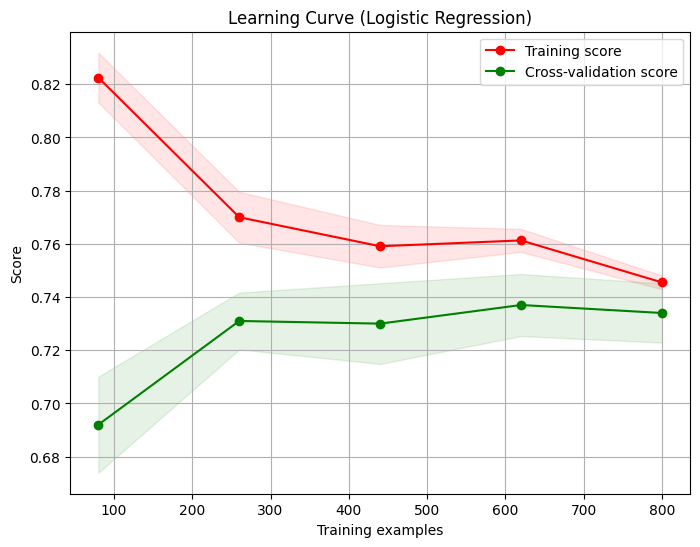

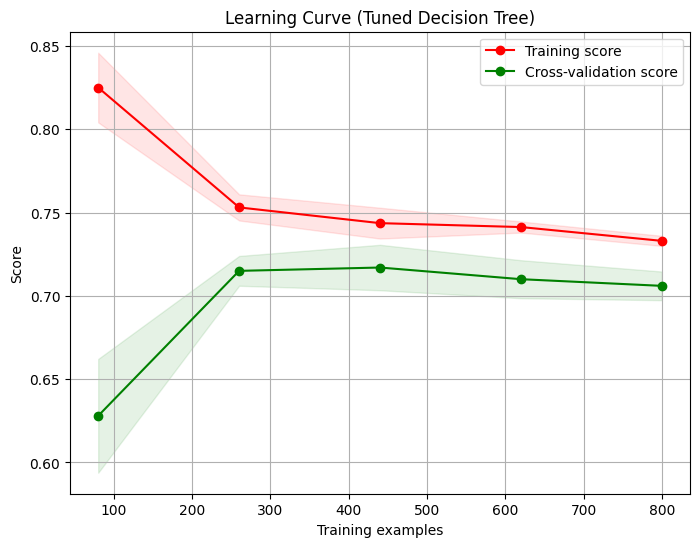

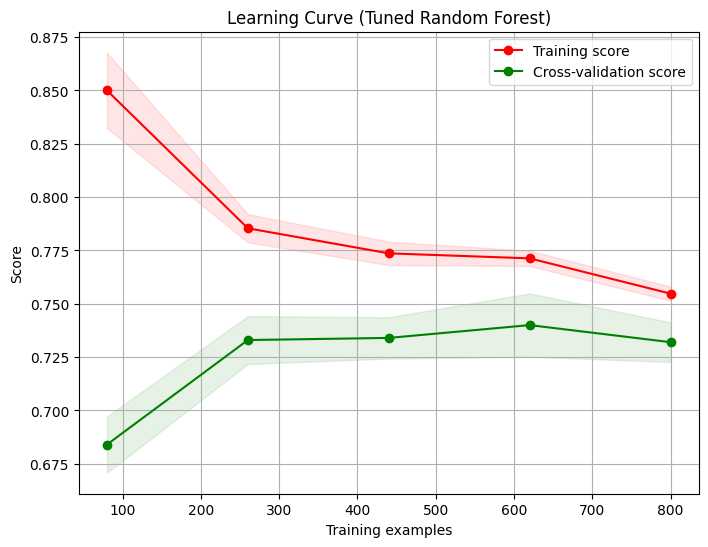

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve

def plot_simplified_learning_curve(estimator, title, X, y, cv=None, n_jobs=None, train_sizes=np.linspace(.1, 1.0, 5)):
    """
    Plots a simplified learning curve showing only training and cross-validation scores.
    """
    plt.figure(figsize=(8, 6))
    plt.title(title)
    plt.xlabel("Training examples")
    plt.ylabel("Score")
    plt.grid()

    train_sizes, train_scores, test_scores, _, _ = \
        learning_curve(estimator, X, y, cv=cv, n_jobs=n_jobs,
                       train_sizes=train_sizes, scoring='accuracy',
                       return_times=True)

    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)

    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1,
                     color="r")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1,
                     color="g")
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r",
             label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g",
             label="Cross-validation score")
    plt.legend(loc="best")
    plt.show()

# Plot learning curve for Logistic Regression
plot_simplified_learning_curve(logistic_regression_model, "Learning Curve (Logistic Regression)", X, y, cv=cv, n_jobs=-1)

# Plot learning curve for Tuned Decision Tree
plot_simplified_learning_curve(best_dt_model, "Learning Curve (Tuned Decision Tree)", X, y, cv=cv, n_jobs=-1)

# Plot learning curve for Tuned Random Forest
plot_simplified_learning_curve(best_rf_model, "Learning Curve (Tuned Random Forest)", X, y, cv=cv, n_jobs=-1)

# **Conclusion**

'Tuned Random Forest' is the best.
Because it uses the 'team of experts' approach. By combining many different decision trees, it makes fewer mistakes and is better at handling the different student situations. It's more reliable than a single decision tree or the simpler Logistic Regression.

So, if we want to predict whether a student will pass or fail based on their scores and other details, the Tuned Random Forest Classifier is our top recommendation!